In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc
import platform

# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac
    rc('font', family='AppleGothic')
elif platform.system() == 'Linux': # Colab 등
    rc('font', family='NanumBarunGothic')

#### MNIST
---

In [93]:
import tensorflow as tf
import keras
from keras import Sequential
from keras.layers import Input, Dense, Flatten
from keras.datasets.mnist import load_data

##### 데이터 나누기

In [94]:
(x_train, y_train), (x_test, y_test) = load_data()

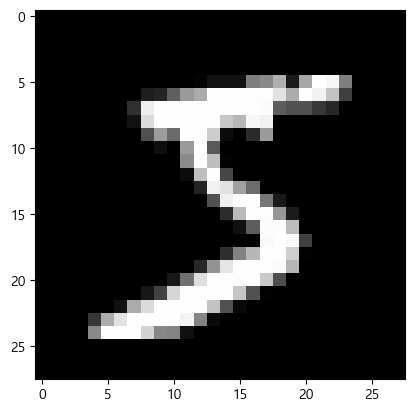

In [95]:
plt.imshow(x_train[0], cmap='gray')
plt.show()

In [96]:
x_train.shape

(60000, 28, 28)

In [97]:
x_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [98]:
# 0-255 값을 0-1 사이의 실수로 변환 : 표준화
x_trainR = x_train.astype('float32') / 255.0
x_testR = x_test.astype('float32') / 255.0

- 255를 나눠 표준화 시키는 이유?
    - 픽셀의 최대값이 '255'이기 때문
    - 전체 데이터를 최대값 255로 나누면 0 ~ 1 사이의 비율로 압축됨
        - 0이었던 픽셀: $0 \div 255 = 0.0$ (여전히 검은색)
        - 127이었던 픽셀: $127 \div 255 \approx 0.5$ (회색)
        - 255였던 픽셀: $255 \div 255 = 1.0$ (흰색)

In [99]:
x_trainR[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [100]:
# x_train.reshape(60000, -1) - shape = (60000, 784)

model = Sequential([
    #(Dense(input_shape=(784,)))
    Input(shape=(28,28)),
    Flatten(),
    (Dense(64, activation='relu')),
    (Dense(32, activation='relu')),
    (Dense(10, activation='softmax'))
])
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['acc'])
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,650 (205.66 KB)

 Trainable params: 52,650 (205.66 KB)

 Non-trainable params: 0 (0.00 B)

In [101]:
model.fit(x_trainR, y_train, epochs=10,
          validation_data=(x_trainR, y_train), verbose=1)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - acc: 0.9173 - loss: 0.2880 - val_acc: 0.9583 - val_loss: 0.1412
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - acc: 0.9611 - loss: 0.1304 - val_acc: 0.9718 - val_loss: 0.0953
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - acc: 0.9712 - loss: 0.0954 - val_acc: 0.9797 - val_loss: 0.0665
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - acc: 0.9759 - loss: 0.0761 - val_acc: 0.9798 - val_loss: 0.0647
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - acc: 0.9808 - loss: 0.0622 - val_acc: 0.9857 - val_loss: 0.0460
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - acc: 0.9829 - loss: 0.0536 - val_acc: 0.9887 - val_loss: 0.0384
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - acc: 0.9860 - loss: 0.0439 - val_acc: 0.9887 - val_loss: 0.0345
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - acc: 0.9870 - loss: 0.0394 - val_acc: 0.9895 - val_loss: 0.0323
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━

In [102]:
pred_num = model.predict(x_testR[3].reshape(1, 28, 28)).argmax()
print(f"x_testR[3]의 예측 결과: {pred_num}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
x_testR[3]의 예측 결과: 0


In [103]:
print(f"x_testR[3]의 실제 정답: {y_test[3]}")

x_testR[3]의 실제 정답: 0


In [104]:
model.predict(x_testR[0].reshape(1,28,28)).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


array([7])

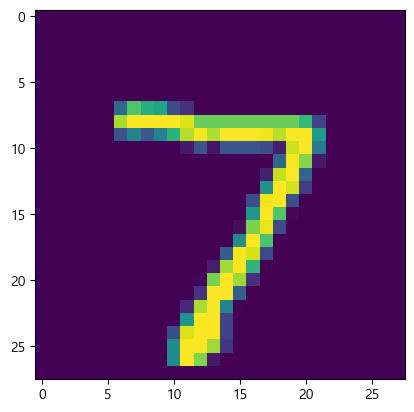

In [105]:
plt.imshow(x_testR[0])
plt.show()

In [106]:
p = model.predict(x_testR[5].reshape(1,28,28))
p.argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


array([1])

1


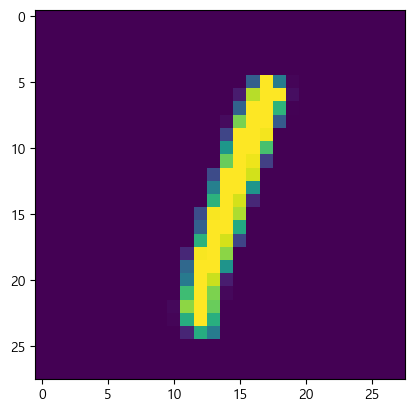

In [107]:
print(y_test[5])
plt.imshow(x_testR[5])
plt.show()

In [108]:
_, acc = model.evaluate(x_testR, y_test, verbose=1)            # 정확도 평가, 검증 데이터로
print(acc)                                                    # 유사한 수준

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 909us/step - acc: 0.9717 - loss: 0.1121
0.9717000126838684


In [109]:
_, acc = model.evaluate(x_trainR, y_train, verbose=1)            # 정확도 평가, 검증 데이터로
print(acc)                                                    # 유사한 수준

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 878us/step - acc: 0.9900 - loss: 0.0300
0.9900166392326355


---
### titanic
---

In [110]:
TITANIC_URL = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
titanic = pd.read_csv(TITANIC_URL)

# TODO : 'Age' 결측치 처리
# 호칭별 평균/중앙값으로 채우기
# 호칭(Title) 추출
titanic['Title'] = titanic['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
# 호칭별 나이 중앙값으로 결측치 채우기
titanic['Age'] = titanic['Age'].fillna(titanic.groupby('Title')['Age'].transform('median'))
# 혹시 남은 결측치는 전체 중앙값으로 보완
titanic['Age'] = titanic['Age'].fillna(titanic['Age'].median())

# TODO : 'Cabin' 결측치 처리
# 방 번호(Cabin)가 기록되지 않은 승객들은
# 주로 낮은 등급 객실(3등석)을 이용했을 확률이 높음.
# 즉, "기록이 없다"는 사실 자체가 생존율과 연관된 힌트
# 첫 글자만 추출하고, 결측치는 'N'으로 채우기
titanic['Cabin'] = titanic['Cabin'].fillna('N')
titanic['Deck'] = titanic['Cabin'].str[0]

# TODO : 'Embarked' 결측치 처리
# 1등석 요금 80달러 근처 승객들의 항구 최빈값 찾기
fare_filter = (titanic['Fare'] >= 70) & (titanic['Fare'] <= 90) & (titanic['Pclass'] == 1)
recommended_port = titanic[fare_filter]['Embarked'].mode()[0] # 결과로 'C'가 나옵니다.

# 2. 결측치 채우기
titanic['Embarked'] = titanic['Embarked'].fillna(recommended_port)

<>:7: SyntaxWarning: invalid escape sequence '\.'
<>:7: SyntaxWarning: invalid escape sequence '\.'
C:\Users\금정산2-PC02\AppData\Local\Temp\ipykernel_14624\1613796195.py:7: SyntaxWarning: invalid escape sequence '\.'
  titanic['Title'] = titanic['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


In [111]:
t_data = titanic.copy()
t_data.drop(columns=['Survived','Name','Ticket', 'Cabin'], inplace=True)
t_label = titanic['Survived']

In [117]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 범주형(문자열) 피처 원-핫 인코딩 진행
# 변환할 컬럼 지정 (Sex, Embarked, Deck, Title)
categorical_cols = ['Sex', 'Embarked', 'Deck', 'Title']
t_data_encoded = pd.get_dummies(t_data, columns=categorical_cols, drop_first=True)

# 딥러닝 연산을 위해 True/False 데이터를 1과 0으로 변환
t_data_encoded = t_data_encoded.astype('float32')

print("인코딩 후 데이터 형태(Shape):", t_data_encoded.shape)

인코딩 후 데이터 형태(Shape): (891, 33)


In [118]:
train_input, test_input, train_label, test_label = train_test_split(
    t_data_encoded, t_label, test_size=0.2, random_state=42, stratify=t_label
)

In [122]:
# 수치형 데이터 스케일링 (평균 0, 표준편차 1로 스케일링)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_input)
X_test_scaled = scaler.transform(test_input)

# 데이터 타입 최종 점검 (y라벨도 float32나 정수형으로 맞춰줍니다)
y_train = train_label.astype('float32')
y_test = test_label.astype('float32')

print("최종 훈련 데이터 shape:", X_train_scaled.shape)

최종 훈련 데이터 shape: (712, 33)


In [127]:
# 1차원 데이터 특성의 수 = 피처의 수
# 생존(1)과 사망(0) 두가지 상태의 확률값 - 1을 알면 자연히 0일 확률도 알 수 있기 때문에 출력 1
model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['acc']
)

model.fit(
    X_train_scaled, y_train,
    epochs=30,
    validation_data=(X_test_scaled, y_test)
)

Epoch 1/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - acc: 0.6194 - loss: 0.6856 - val_acc: 0.7318 - val_loss: 0.5872
Epoch 2/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7992 - loss: 0.5284 - val_acc: 0.7933 - val_loss: 0.5133
Epoch 3/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8160 - loss: 0.4543 - val_acc: 0.8268 - val_loss: 0.4780
Epoch 4/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8329 - loss: 0.4154 - val_acc: 0.8156 - val_loss: 0.4624
Epoch 5/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8497 - loss: 0.3954 - val_acc: 0.8324 - val_loss: 0.4536
Epoch 6/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8497 - loss: 0.3840 - val_acc: 0.8380 - val_loss: 0.4488
Epoch 7/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8581 - loss: 0.3756 - val_acc: 0.8380 - val_loss: 0.4446
Epoch 8/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8567 - loss: 0.3720 - val_acc: 0.8380 - val_loss: 0.4434
Epoch 9/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8539 - loss: 

- 유닛 수 조절, 에포크 변경을 시도해봤음에도 acc 0.87 정도
- 데이터가 작고, 정보가 제한적, 데이터 외의 정보들

- acc : 맞춘 문제의 개수
- loss : 모델이 느낀 반성 점수(틀린 자책감의 크기 ㅋㅋ)

- acc(높음), loss(낮음) : 학습 잘하고 있음
- val_acc(낮음), val_loss(높음) : 응용 못하고 헤메는 중
    - loss와 val_loss 사이의 격차가 벌어지는 현상 - 과적합으로 볼 수 있음

##### 학습시 확인할 것
- acc, val_acc가 둘 다 높으면서 서로 차이가 크지 않은지 확인
- loss가 떨어지는데 val_loss가 높아진다면 학습을 멈춰야함
    - 타이타닉 학습에서 최적의 Epoch 지점 12